In [1]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector

simulator = AerSimulator()
print("Qiskit environment successfully loaded.")

Qiskit environment successfully loaded.


In [2]:
def run_quantum_coin_game(classical_choice="keep"):
    """
    Builds and executes the Quantum Coin Flip Game circuit.
    
    Parameters:
        classical_choice (str): 'keep' (Identity gate) or 'flip' (X gate)
    """
    # 1-qubit circuit with 1 classical bit for measurement
    qc = QuantumCircuit(1, 1, name=f"Coin Game ({classical_choice.upper()})")
    
    # --- Turn 1: Quantum Player (Picard) puts coin into superposition ---
    qc.h(0)
    qc.barrier()
    
    # --- Turn 2: Classical Player (Q) makes a move ---
    if classical_choice.lower() == "flip":
        qc.x(0)  # Classical bit flip (X gate)
    elif classical_choice.lower() == "keep":
        qc.id(0) # Keep coin as is (Identity gate)
    else:
        raise ValueError("Choice must be 'keep' or 'flip'")
    qc.barrier()
    
    # --- Turn 3: Quantum Player (Picard) applies final Hadamard ---
    qc.h(0)
    qc.barrier()
    
    return qc

# Generate circuits for both strategies
qc_keep = run_quantum_coin_game(classical_choice="keep")
qc_flip = run_quantum_coin_game(classical_choice="flip")

print("Circuits created successfully.")

Circuits created successfully.


=== Circuit Strategy 1: Classical Player chooses 'KEEP' ===


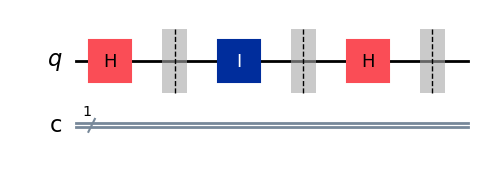

=== Circuit Strategy 2: Classical Player chooses 'FLIP' ===


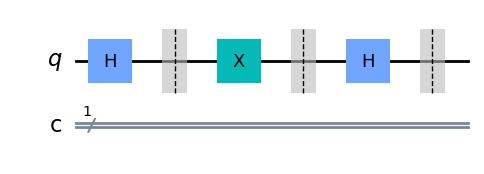

In [3]:
print("=== Circuit Strategy 1: Classical Player chooses 'KEEP' ===")
display(qc_keep.draw(output='mpl', style='iqp'))

print("=== Circuit Strategy 2: Classical Player chooses 'FLIP' ===")
display(qc_flip.draw(output='mpl', style='clifford'))

=== Analytical Results ===
Final Statevector when Classical Player KEEPS: [1.+0.j 0.+0.j]
Final Statevector when Classical Player FLIPS: [1.+0.j 0.+0.j]


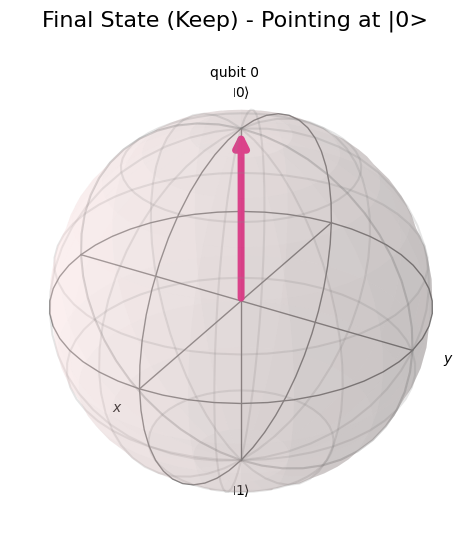

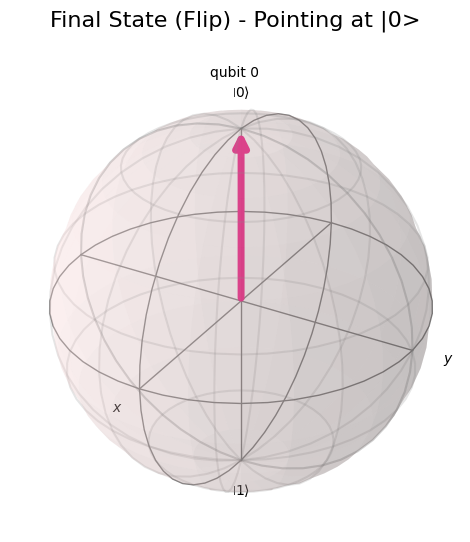

In [4]:
# Analyze final statevectors before measurement
state_keep = Statevector.from_instruction(qc_keep)
state_flip = Statevector.from_instruction(qc_flip)

print("=== Analytical Results ===")
print("Final Statevector when Classical Player KEEPS:", state_keep.data)
print("Final Statevector when Classical Player FLIPS:", state_flip.data)

# Visualize on Bloch Sphere
display(plot_bloch_multivector(state_keep, title="Final State (Keep) - Pointing at |0>"))
display(plot_bloch_multivector(state_flip, title="Final State (Flip) - Pointing at |0>"))


--- Strategy: Classical Player chooses to 'KEEP' ---
Total Shots: 1000
Outcome Counts: {'0': 1000}
Quantum Player (Picard / Heads) Win Probability: 100.0%
Classical Player (Q / Tails) Win Probability:    0.0%

--- Strategy: Classical Player chooses to 'FLIP' ---
Total Shots: 1000
Outcome Counts: {'0': 1000}
Quantum Player (Picard / Heads) Win Probability: 100.0%
Classical Player (Q / Tails) Win Probability:    0.0%


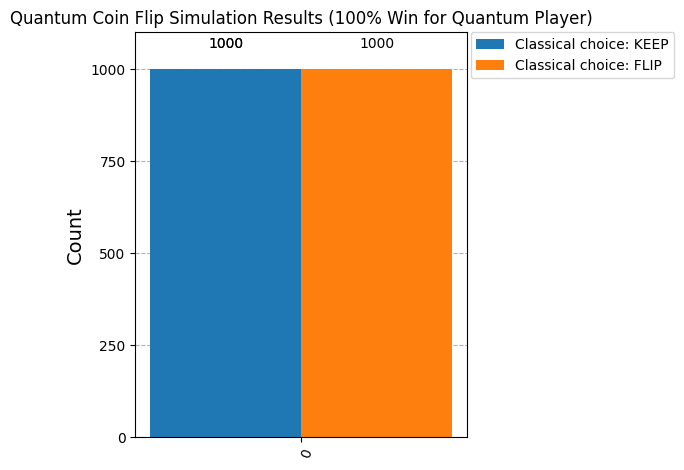

In [5]:
def verify_win_probabilities(qc, strategy_name, shots=1000):
    # Add measurement step
    qc_measured = qc.copy()
    qc_measured.measure(0, 0)
    
    # Run simulation
    counts = simulator.run(qc_measured, shots=shots).result().get_counts()
    
    # Calculate probabilities
    heads_count = counts.get('0', 0)
    tails_count = counts.get('1', 0)
    
    picard_win_prob = (heads_count / shots) * 100
    q_win_prob = (tails_count / shots) * 100
    
    print(f"\n--- Strategy: Classical Player chooses to '{strategy_name}' ---")
    print(f"Total Shots: {shots}")
    print(f"Outcome Counts: {counts}")
    print(f"Quantum Player (Picard / Heads) Win Probability: {picard_win_prob:.1f}%")
    print(f"Classical Player (Q / Tails) Win Probability:    {q_win_prob:.1f}%")
    
    return counts

# Run simulations
counts_keep = verify_win_probabilities(qc_keep, "KEEP")
counts_flip = verify_win_probabilities(qc_flip, "FLIP")

# Plot measurement results histogram
plot_histogram([counts_keep, counts_flip], 
               legend=["Classical choice: KEEP", "Classical choice: FLIP"],
               title="Quantum Coin Flip Simulation Results (100% Win for Quantum Player)")